In [104]:
# !pip install pandas numpy matplotlib mplsoccer seaborn scikit-learn

# I imported data and loaded it

In [105]:
import pandas as pd
import numpy as np


In [106]:
from google.colab import files
uploaded = files.upload()

Saving xg_model.xlsx to xg_model (1).xlsx


In [107]:
df= pd.read_excel('xg_model.xlsx')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8118 entries, 0 to 8117
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   x                8118 non-null   float64
 1   y                8118 non-null   float64
 2   is_goal          8118 non-null   bool   
 3   period           8118 non-null   object 
 4   Assisted         6038 non-null   float64
 5   Zone             8118 non-null   object 
 6   IndividualPlay   2802 non-null   float64
 7   RegularPlay      5390 non-null   float64
 8   LeftFoot         2791 non-null   float64
 9   RightFoot        3994 non-null   float64
 10  FromCorner       1194 non-null   float64
 11  FirstTouch       3925 non-null   float64
 12  Head             1300 non-null   float64
 13  BigChance        1607 non-null   float64
 14  SetPiece         393 non-null    float64
 15  Volley           810 non-null    float64
 16  FastBreak        616 non-null    float64
 17  ThrowinSetPiec

# Data Description
1. x, y (float64)
What it is: The coordinates on the pitch where the shot was taken.
Why it matters: Shot location is the single most important predictor for xG. Shots closer to goal or central are more likely to be scored.
2. is_goal (bool)
What it is: Whether the shot resulted in a goal (1) or not (0).
Why it matters: This is your target variable in the model.
3. period (object)
What it is: The game period (e.g., “1st half”, “2nd half”).
Why it matters: Timing can matter in some cases (e.g., fatigue, defensive adjustments), but less important than location.
4. Assisted (object)
What it is: Whether the shot was assisted, and possibly by which type of pass.
Why it matters: Assisted shots tend to have higher xG than solo shots.
5. Zone (object)
What it is: Area of the pitch (e.g., “Penalty area”, “Outside box”).
Why it matters: Zone approximates distance and angle to goal. Central zones are higher xG.
6. IndividualPlay (object)
What it is: Whether the shot came from a solo effort or dribble.
Why it matters: Individual plays can be harder for defenders to stop, potentially increasing xG.
7. RegularPlay (object)
What it is: Standard open play shot (not set piece, corner, etc.).
Why it matters: Distinguishes normal play from set pieces, which have different scoring probabilities.
8. LeftFoot / RightFoot (object)
What it is: Foot used for the shot.
Why it matters: For most players, shots with dominant foot are more accurate → higher xG.
9. FromCorner (object)
What it is: Shot came from a corner kick.
Why it matters: Corner shots usually have low xG unless very close to goal.
10. FirstTouch (object)
What it is: Whether it was a first-touch shot.
Why it matters: First-touch shots are often harder to place → lower xG.
11. Head (object)
What it is: Whether the shot was a header.
Why it matters: Headers are usually less accurate than shots with feet → lower xG.
12. BigChance (object)
What it is: If the shot was considered a “big chance” (clear scoring opportunity).
Why it matters: Big chances have very high xG.
13. SetPiece (object)
What it is: Shot from a free kick, penalty, or corner.
Why it matters: Set pieces have a different scoring probability than open play.
14. Volley (object)
What it is: Shot taken as a volley.
Why it matters: Volleys can be harder to score → usually lower xG, but depends on distance.
15. FastBreak (object)
What it is: Shot during a counterattack.
Why it matters: Fast break shots often have higher xG because defenders are out of position.
16. ThrowinSetPiece (object)
What it is: Shot immediately following a throw-in.
Why it matters: Usually low xG, but can be interesting for analysis.
17. Penalty (object)
What it is: Shot is a penalty kick.
Why it matters: Almost always very high xG (~0.75–0.8).
18. OneOnOne (object)
What it is: Situation is a one-on-one with the goalkeeper.
Why it matters: High xG because GK is the only obstacle.
19. KeyPass (object)
What it is: Was the shot following a key pass (dangerous assist).
Why it matters: Indicates high-quality chance → higher xG.
20. DirectFreekick (object)
What it is: Shot came directly from a free kick.
Why it matters: Scoring from direct free kicks is low probability → low xG.
21. OwnGoal (object)
What it is: Rare cases where it’s an own goal.
Why it matters: Usually negligible in xG model (very rare, 27 entries).
22. OtherBodyPart (object)
What it is: Shot taken with unusual body part (not foot/head).
Why it matters: Rare, low probability → low xG.
23. DirectCorner (object)
What it is: Extremely rare cases where the ball goes directly from corner → goal.
Why it matters: Can usually be ignored due to only 2 entries.

In [157]:
df.head()

,x,y,is_goal,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,...,OneOnOne,KeyPass,OtherBodyPart,shot_distance,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right
0,80.8,51.6,False,True,True,True,True,False,False,False,...,False,False,False,19.266551,False,True,False,True,False,False
1,79.3,24.2,False,True,True,True,False,True,False,False,...,False,False,False,33.077636,False,True,False,True,False,False
2,80.0,59.5,False,True,False,False,False,True,True,False,...,False,False,False,22.141590,False,True,False,True,False,False
3,89.8,55.6,False,True,False,False,False,False,True,True,...,False,False,False,11.636151,False,True,False,True,False,False
4,84.9,56.2,False,True,False,True,True,False,False,False,...,False,False,False,16.323296,False,True,False,True,False,False


In [159]:
df.to_csv("shots.csv", index=False)
from google.colab import files
files.download("shots.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [110]:
df.shape

(8118, 25)

In [111]:
df.x.max()

99.6

In [112]:
df.x.min()

0.8

In [113]:
df.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'DirectFreekick',
       'OwnGoal', 'OtherBodyPart', 'DirectCorner'],
      dtype='object')

# Data cleaning

In [114]:
df.drop(["DirectFreekick","DirectCorner"],axis=1, inplace=True)

In [115]:
df.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'OwnGoal',
       'OtherBodyPart'],
      dtype='object')

In [116]:
df.OwnGoal.value_counts()

,count
OwnGoal,
1.0,27


In [117]:
df= df[df["OwnGoal"] != True]

In [118]:
df.drop(["OwnGoal"],axis=1, inplace=True)

In [119]:
df.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'OtherBodyPart'],
      dtype='object')

In [120]:
df.shape

(8091, 22)

In [121]:
df.is_goal.value_counts()

,count
is_goal,
False,7097
True,994


# Visualise our target variable

<Axes: xlabel='x', ylabel='y'>

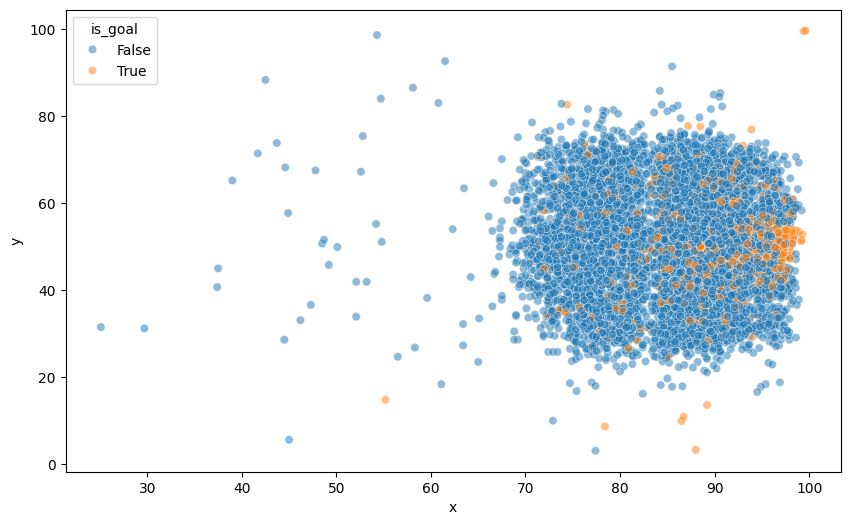

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(x='x', y='y', data=df, hue='is_goal', alpha=.5)

In [123]:
df.isnull().sum()

,0
x,0
y,0
is_goal,0
period,0
Assisted,2053
Zone,0
IndividualPlay,5289
RegularPlay,2714
LeftFoot,5307
RightFoot,4106


In [124]:
df.fillna(0, inplace= True)

In [125]:
df.dtypes

,0
x,float64
y,float64
is_goal,bool
period,object
Assisted,float64
Zone,object
IndividualPlay,float64
RegularPlay,float64
LeftFoot,float64
RightFoot,float64


In [126]:
dtype_dict = {
    'x': float,
    'y': float,
    'is_goal': bool,
    'period': str,
    'Assisted': bool,
    'Zone': str,
    'IndividualPlay': bool,
    'RegularPlay': bool,
    'LeftFoot': bool,
    'RightFoot': bool,
    'FromCorner': bool,
    'FirstTouch': bool,
    'Head': bool,
    'BigChance': bool,
    'SetPiece': bool,
    'Volley': bool,
    'FastBreak': bool,
    'ThrowinSetPiece': bool,
    'Penalty': bool,
    'OneOnOne': bool,
    'KeyPass': bool,
    'OtherBodyPart': bool,
}
# Then apply it to the dataframe
df = df.astype(dtype_dict)

In [127]:
df.dtypes

,0
x,float64
y,float64
is_goal,bool
period,object
Assisted,bool
Zone,object
IndividualPlay,bool
RegularPlay,bool
LeftFoot,bool
RightFoot,bool


# featuring enginering

In [128]:
df['shot_distance'] = np.sqrt((df['x'] - 100)**2 + (df['y'] - 50)**2)

In [129]:
df.shot_distance

,shot_distance
0,19.266551
1,33.077636
2,22.141590
3,11.636151
4,16.323296
...,...
8113,20.999048
8114,7.665507
8115,16.697305
8116,10.572133


<Axes: >

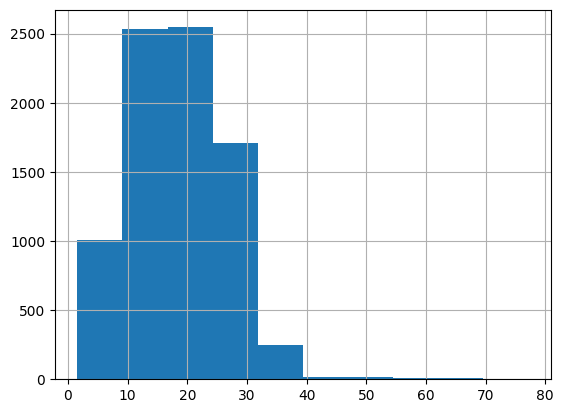

In [130]:
df['shot_distance'].hist()

In [131]:
df['shot_distance'].describe()

,shot_distance
count,8091.000000
mean,18.495064
std,8.011289
min,1.581139
25%,12.061300
50%,18.380696
75%,24.200207
max,77.150891


In [132]:
df.period.value_counts()

,count
period,
SecondHalf,4333
FirstHalf,3758


# Encoding the categorical features

In [133]:
df = pd.get_dummies(df, columns=['period','Zone'])

In [134]:
df.columns

Index(['x', 'y', 'is_goal', 'Assisted', 'IndividualPlay', 'RegularPlay',
       'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch', 'Head',
       'BigChance', 'SetPiece', 'Volley', 'FastBreak', 'ThrowinSetPiece',
       'Penalty', 'OneOnOne', 'KeyPass', 'OtherBodyPart', 'shot_distance',
       'period_FirstHalf', 'period_SecondHalf', 'Zone_Back', 'Zone_Center',
       'Zone_Left', 'Zone_Right'],
      dtype='object')

In [135]:
df.period_FirstHalf.value_counts()

,count
period_FirstHalf,
False,4333
True,3758


In [136]:
df.period_SecondHalf.value_counts()

,count
period_SecondHalf,
True,4333
False,3758


NameError: name 'cshow' is not defined

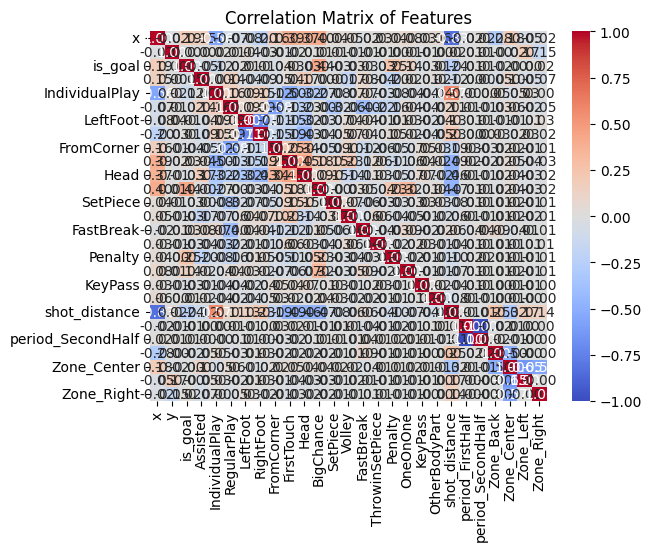

<Figure size 1200x1000 with 0 Axes>

In [138]:
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Features')
plt.figure(figsize=(12,10))
cshow()

In [139]:
from scipy.stats import pearsonr

In [141]:
df_data_corr = df.copy()
df_data_corr["Churn"] = y

corr = df_data_corr.corr()["Churn"].sort_values(ascending=False)
print(corr)

is_goal              1.000000
Churn                1.000000
BigChance            0.437485
Penalty              0.251575
x                    0.185891
OneOnOne             0.141043
FirstTouch           0.031493
FastBreak            0.026206
Zone_Right           0.022448
OtherBodyPart        0.014203
period_SecondHalf    0.011837
LeftFoot             0.010286
RightFoot            0.008610
y                    0.004472
Zone_Center         -0.001120
Zone_Left           -0.004247
period_FirstHalf    -0.011837
RegularPlay         -0.016410
Zone_Back           -0.017672
Volley              -0.026983
Head                -0.027148
SetPiece            -0.027423
ThrowinSetPiece     -0.030002
KeyPass             -0.031800
FromCorner          -0.042496
Assisted            -0.053457
IndividualPlay      -0.118882
shot_distance       -0.237818
Name: Churn, dtype: float64


# Seperate the target

In [142]:
X = df.drop('is_goal', axis=1)
y = df['is_goal']

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score,brier_score_loss

# Train-test split

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the model

In [145]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of goal

In [146]:
y_pred_proba[:10]

array([0.07316349, 0.35086697, 0.03638619, 0.03778513, 0.10020373,
       0.03810524, 0.03488027, 0.04860192, 0.04599387, 0.03884171])

In [147]:
final_df = X_test.copy()
final_df['y_pred_proba'] = y_pred_proba


In [148]:
final_df.iloc[830]

,1808
x,79.1
y,70.3
Assisted,False
IndividualPlay,False
RegularPlay,False
LeftFoot,True
RightFoot,False
FromCorner,False
FirstTouch,False
Head,False


In [156]:
final_df.sort_values(by='y_pred_proba', ascending=False).head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,...,KeyPass,OtherBodyPart,shot_distance,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,y_pred_proba
6619,88.5,50.0,False,False,False,True,False,False,False,False,...,False,False,11.5,False,True,False,True,False,False,0.841312
3671,88.5,50.0,False,False,False,True,False,False,False,False,...,False,False,11.5,False,True,False,True,False,False,0.841312
1323,88.5,50.0,False,False,False,True,False,False,False,False,...,False,False,11.5,False,True,False,True,False,False,0.841312
381,88.5,50.0,False,False,False,True,False,False,False,False,...,False,False,11.5,False,True,False,True,False,False,0.841312
695,88.5,50.0,False,False,False,True,False,False,False,False,...,False,False,11.5,True,False,False,True,False,False,0.838067


# Evaluating the model

In [149]:
log_loss(y_test, y_pred_proba)



0.26947676439820983

# What it means
Log Loss measures how close your predicted probabilities (xG) are to the actual outcomes (is_goal).
Lower is better.
Perfect predictions → 0
Random guessing → ~0.693 for a balanced binary dataset (log(2))

Your dataset is imbalanced (~12% goals), so 0.27 is actually pretty reasonable for a first model.

# How to interpret in football terms
Each shot’s predicted xG is compared to whether it actually scored.
A Log Loss of 0.27 means your model is doing a good job predicting probabilities, not just yes/no outcomes.
This is exactly what professional analysts look at when evaluating xG models.

In [150]:
roc_auc_score(y_test, y_pred_proba)


np.float64(0.8109528859263748)

In [151]:
brier_score_loss(y_test, y_pred_proba)

np.float64(0.0772776879725815)

In [152]:
!pip install mplsoccer

In [153]:
from mplsoccer import Pitch
pitch= Pitch(pitch_type='opta')

In [154]:
from matplotlib.colors import LinearSegmentedColormap
colors= ['red', 'yellow','green']
cmap = LinearSegmentedColormap.from_list("shot_cmap", colors)

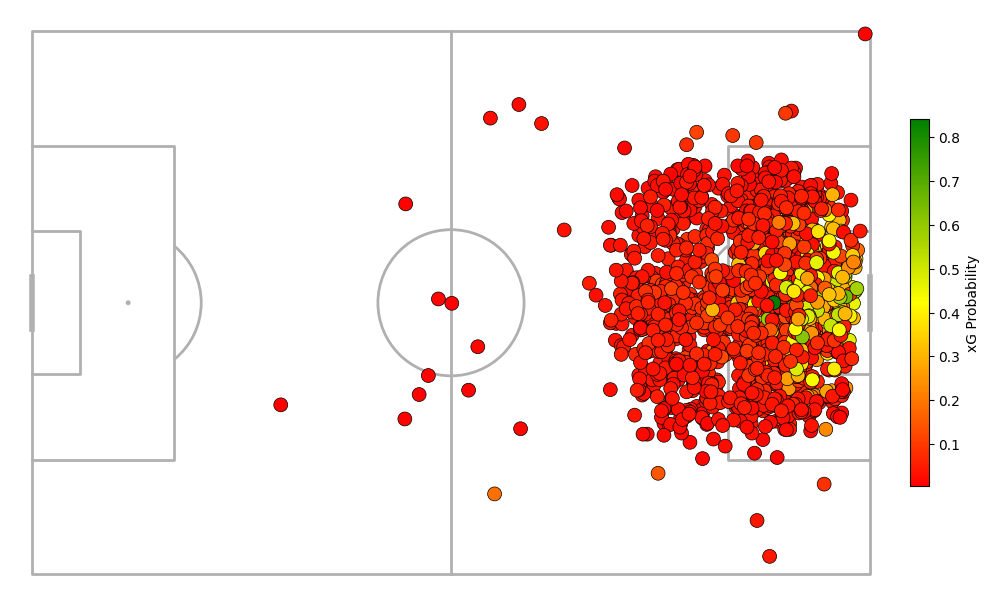

In [155]:
fig, ax = pitch.draw(figsize=(10,8))
sc= pitch.scatter(
final_df['x'],
final_df['y'],
c= final_df['y_pred_proba'],
cmap= cmap,
edgecolors= 'black',
linewidth=.5,
s=100,
ax=ax
)
cbar= plt.colorbar(sc, ax=ax, orientation='vertical', fraction=.02, pad=.02)
cbar.set_label('xG Probability')